# Using notebook for prototyping

We use the notebook to solve a Diffusion-Reaction PDE on $(t,x) \in [0, 1]\times [-\pi, +\pi]$
$$ 
\partial_t u(t,x) = \partial_x^2 u(t,x) + \mathrm{e}^{-t} f(x) \,, \qquad f(x) \equiv \frac{3 \sin (2x)}{2} + \frac{8 \sin (3x)}{3}  + \frac{15 \sin (4x)}{4}  + \frac{63 \sin (8x)}{8} 
$$
with
$$
(\mathrm{IC})  \qquad u(t=0, x) = \sin x + \frac{\sin (2x)}{2} + \frac{\sin (3x)}{3} + \frac{\sin (4x)}{4}  + \frac{\sin (8x)}{8} 
$$
and
$$
(\mathrm{BC})  \qquad u(t, x = \pm \pi) = 0.
$$

We can check against the _exact_ solution
$$
u_{\mathrm{exact}} (t,x) = \mathrm{e}^{-t} \left(  \sin x + \frac{\sin (2x)}{2} + \frac{\sin (3x)}{3} + \frac{\sin (4x)}{4}  + \frac{\sin (8x)}{8}  \right)
$$

## 0. Loading conf files

In [1]:
from physicsnemo.sym.hydra import to_yaml
from physicsnemo.sym.hydra.utils import compose
# must be passed to ensure no bug arises 
# https://github.com/NVIDIA/physicsnemo-sym/issues/206
from physicsnemo.sym.hydra.utils import register_amp_configs
register_amp_configs()  

cfg = compose(config_path="./notebook_conf/", config_name="config")
cfg.network_dir = "notebook_outputs"  # Set the network directory for checkpoints
cfg.optimizer.lr = 0.0005 #<=== update optimiser
print(to_yaml(cfg))

/usr/local/lib/python3.12/dist-packages/physicsnemo/sym/hydra/utils.py:156: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(
TorchScript default is being turned off due to PyTorch version mismatch.


training:
  max_steps: 10000
  grad_agg_freq: 1
  rec_results_freq: 1000
  rec_validation_freq: 100
  rec_inference_freq: 100
  rec_monitor_freq: 100
  rec_constraint_freq: 100
  save_network_freq: 1000
  print_stats_freq: 100
  summary_freq: 1000
  grad_clip_max_norm: 0.5
  monitor_grad_clip: true
  ntk:
    use_ntk: false
    save_name: null
    run_freq: 1000
amp:
  enabled: false
  mode: per_order_scaler
  dtype: float16
  autocast_activation: false
  autocast_firstlayer: false
  default_max_scale_log2: 0
  custom_max_scales_log2: {}
graph:
  func_arch: true
  func_arch_allow_partial_hessian: true
stop_criterion:
  metric: null
  min_delta: null
  patience: 50000
  mode: min
  freq: 1000
  strict: false
profiler:
  profile: false
  start_step: 0
  end_step: 100
  name: nvtx
network_dir: notebook_outputs
initialization_network_dir: ''
save_filetypes: vtk
summary_histograms: 'off'
jit: true
jit_use_nvfuser: true
jit_arch_mode: only_activation
jit_autograd_nodes: false
cuda_graphs: tr

## 1. Define PDE class

In [2]:
from sympy import Symbol, Eq, Abs, And, Or, Xor, Function, Number
from sympy import atan2, pi, sin, cos

from physicsnemo.sym.eq.pde import PDE

class ReactionDiffusion(PDE):
    """
    Continuity equation 1D
    The equation is given as an example for implementing
    your own PDE.
        u_t - u_xx - f = 0
    """

    name = "ReactDiffusion"

    def __init__(self, u: str = 'u'):
        # coordinates
        x = Symbol("x")
        # time
        t = Symbol("t")
        # make input variables
        input_variables = {"x": x, "t": t}
        # make u function
        u = Function("u")(*input_variables)

        diffusion = u.diff(t) - u.diff(x, 2)
        reaction  = 0
        dict_of_coeff = {
            1: 0, 
            2: 3, 
            3: 8, 
            4: 15,
            8: 63
        }
        for n in [1,2,3,4,8]:
            reaction += dict_of_coeff[n] * sin(n*x)/n

        # set equations
        self.equations = {}
        self.equations["reactdiff"] = diffusion - reaction

In [3]:
pde = ReactionDiffusion(u="u")

In [4]:
print("PDE equation:")
display(pde.equations["reactdiff"])

PDE equation:


-3*sin(2*x)/2 - 8*sin(3*x)/3 - 15*sin(4*x)/4 - 63*sin(8*x)/8 + Derivative(u(x, t), t) - Derivative(u(x, t), (x, 2))

## 2. Define Geometry & IC

In [5]:
from physicsnemo.sym.geometry.primitives_1d import Line1D

x, t_symbol = Symbol("x"), Symbol("t")
time_range = {t_symbol: (0.0, 1.0)}

# geo
_ell = float(pi)
geo_1D = Line1D(point_1 = -_ell, point_2 = +_ell)
# Initial condition
ic_expr = 0
for n in [1,2,3,4,8]:
    ic_expr += sin(n*x)/n
ic_dict = {
    "u": ic_expr
}

In [6]:
print("BC:")
display(geo_1D.bounds.bound_ranges)
print("\n\nIC:")
display(ic_expr)

BC:


{x: (-3.141592653589793, 3.141592653589793)}



IC:


sin(x) + sin(2*x)/2 + sin(3*x)/3 + sin(4*x)/4 + sin(8*x)/8

## 3. Define model

In [7]:
from physicsnemo.sym.key import Key
from physicsnemo.sym.models.fully_connected import FullyConnectedArch
from physicsnemo.sym.models.activation import Activation

def get_model():
    flow_net = FullyConnectedArch(
        input_keys = [Key("x"), Key("t")],
        output_keys= [Key("u")],
        # Arch Specs
        layer_size = 64,
        nr_layers = 4, 
        skip_connections = True, 
        adaptive_activations = True, 
        activation_fn = Activation.SILU, 
    )
    
    return flow_net

In [8]:
flow_net = get_model()

In [9]:
print("Model:")
display(flow_net)

Model:


FullyConnectedArch(
  (_impl): FullyConnectedArchCore(
    (layers): ModuleList(
      (0): FCLayer(
        (linear): WeightNormLinear(in_features=2, out_features=64, bias=True)
      )
      (1-3): 3 x FCLayer(
        (linear): WeightNormLinear(in_features=64, out_features=64, bias=True)
      )
    )
    (final_layer): FCLayer(
      (activation_fn): Identity()
      (linear): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)

# 4. Domain

### 4.0. Nodes

In [10]:
nodes = pde.make_nodes() + [flow_net.make_node(name="flow_network")]

In [11]:
nodes[0].name

'Sympy Node: reactdiff'

### 4.1. Constraints

In [12]:
from physicsnemo.sym.geometry.parameterization import Parameterization

In [13]:
from physicsnemo.sym.domain import Domain
from physicsnemo.sym.domain.constraint import (
    PointwiseBoundaryConstraint,
    PointwiseInteriorConstraint,
)

domain = Domain()   # <====== DOMAIN instance =======
# Interior
interior = PointwiseInteriorConstraint(
    nodes    = nodes,
    geometry = geo_1D,
    outvar   = {"reactdiff": 0},
    batch_size = 4096,
    parameterization = time_range,
)
domain.add_constraint(interior, "interior")
# BC
BC = PointwiseBoundaryConstraint(
    nodes    = nodes,
    geometry = geo_1D,
    outvar   = {"u": 0},
    batch_size= 1024,
    parameterization = time_range,
)
domain.add_constraint(BC, "BC")
# initial condition
IC = PointwiseInteriorConstraint(
    nodes    = nodes,
    geometry = geo_1D,
    outvar   = ic_dict,  
    batch_size = 1024,
    lambda_weighting = {"u": 1.0},
    parameterization = {t_symbol: 0.0},
)
domain.add_constraint(IC, "IC")  

### 4.2. Inference & Validations

In [14]:
from physicsnemo.sym.domain.validator  import PointwiseValidator
from physicsnemo.sym.domain.inferencer import PointwiseInferencer

from physicsnemo.sym.utils.io import (
    ValidatorPlotter,
    InferencerPlotter,
)

In [15]:
import numpy as np
# ====== inferencer ===========================
# add inferencer data
deltaT = 0.01
deltaX = 0.01
x = np.arange(-_ell, +_ell, deltaX)
t = np.arange(0, 1.0, deltaT)
X, T = np.meshgrid(x, t)
X = np.expand_dims(X.flatten(), axis=-1)
T = np.expand_dims(T.flatten(), axis=-1)
invar_numpy  = {"x": X, "t": T}

grid_inference = PointwiseInferencer(
    nodes = nodes,
    invar = invar_numpy,
    output_names = ["u"],
    batch_size = 1024,
    plotter    = InferencerPlotter(),
)
domain.add_inferencer(grid_inference, "inf_data")

In [16]:
# ====== validator ===========================
# add validation data
pi_fact = float(pi)
u_sol = 0 
for n in [1,2,3,4,8]:
    u_sol += np.exp(- T) * np.sin( n*X )/n

outvar_numpy = {"u": u_sol}
validator = PointwiseValidator(
    nodes=nodes, invar=invar_numpy, true_outvar=outvar_numpy, batch_size=256 ,
    plotter=ValidatorPlotter(),
)
domain.add_validator(validator)

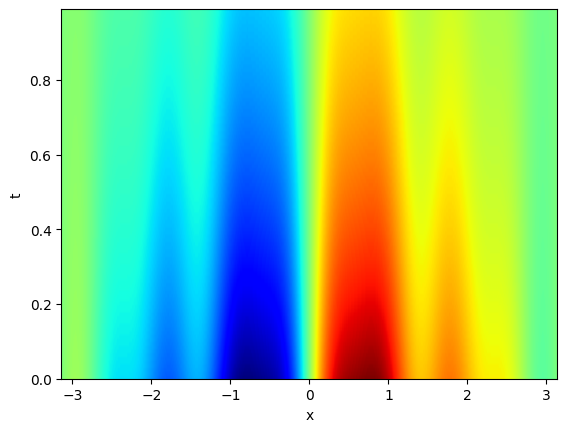

In [17]:
import matplotlib.pyplot as plt 

plt.figure(dpi=100)
plt.imshow( 
    u_sol.reshape([*t.shape, *x.shape]) , 
    cmap='jet', origin='lower', aspect='auto',
    extent = [
         x.min(), x.max(),
         t.min(), t.max()
    ]
)
plt.xlabel('x')
plt.ylabel('t')
plt.show()

## 5. Solver

In [18]:
from physicsnemo.sym.solver import Solver

# to make the logging work in the jupyter cells
# execute this cell only once
import logging

logging.getLogger().addHandler(logging.StreamHandler())

# make solver
slv = Solver(cfg, domain)

# start solver
slv.solve()

Installed PyTorch version 2.7.0a0+79aa17489c.nv25.04 is not TorchScript supported in PhysicsNeMo. Version 2.1.0a0+4136153 is officially supported.
/usr/local/lib/python3.12/dist-packages/physicsnemo/sym/amp.py:221: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  super().__init__(*args, **kwargs)
attempting to restore from: /home/private/PINN2026/4. Advanced PhysicsNemo/notebook_outputs
optimizer checkpoint not found
model flow_network.0.pth not found
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
[step:          0] saved constraint results to notebook_outputs
[step:          